<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/04_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seaborn

In [ ]:
import seaborn as sns
print(sns.__version__)

0.13.2


- 파이썬의 대표적 통계데이터 시각화 library
- matplotlib기반으로 pandas data structure와 통합된다
- 대부분 floating 함수를 통해 이루어짐
- 참조
https://seaborn.pydata.org/tutorial.html

- seaborn 함수들은 크게 'feature-level'또는 'axes-level'함수로 나뉘어져 있음

- 첫 번째로 figure-level 함수
  - figure-level 함수는 matplotlib와 별개로 seaborn의 figure를 만들어 그 곳에 plotting한다고 볼 수 있음
  - 따라서 figure-level함수를 사용하여 seaborn 사용한 경우에는 facetgrid(seaborn의 figure)를 통해 레이아웃을 변경한다.
  
- axes-level: axes 수준에서 plotting을 하는 함수이며, plt.figure()와 같은 함수로 레이아웃을 변경한다.

- 세 개의 박스가 figure-level 함수
  - 그 아래 작은 박스들이 axes-level함수

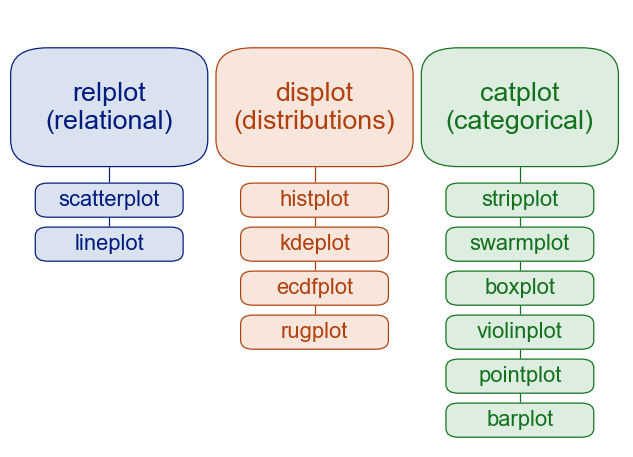

- countplot()
  - 범주형 데이터를 입력하면, 항목별로 개수를 세어서 막대그래프를 그려준다.
  - pandas의 value_counts()와 비교하면 이해하기 쉽다.
  - 맵플롯립의 bar() 함수와 다른 점을 이해한다.
- barplot()
  - y축으로 설정된 값의 평균을 막대의 높이로 표현한다.
  - estimator 인수: y축에 표시될 값을 계산하는 방법을 지정할 수 있다.

- 막대그래프

In [ ]:
import pandas as pd

filename = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips=pd.read_csv(filename)
tips.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


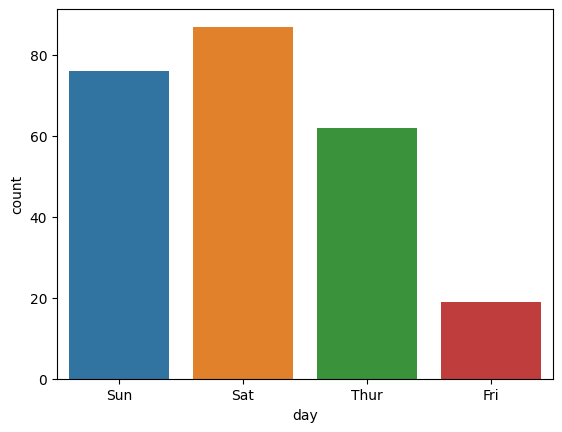

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=tips, x='day', hue='day')
plt.show()

In [ ]:
x=tips['day'].value_counts()
print(x)

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


- hue 인수
  - hue 파라미터 설정, 종류별로 분리해서 그래프 그림

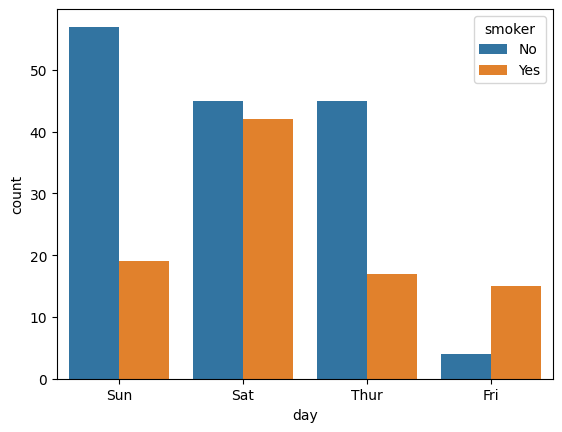

In [ ]:
sns.countplot(data=tips, x='day', hue='smoker')
plt.show()

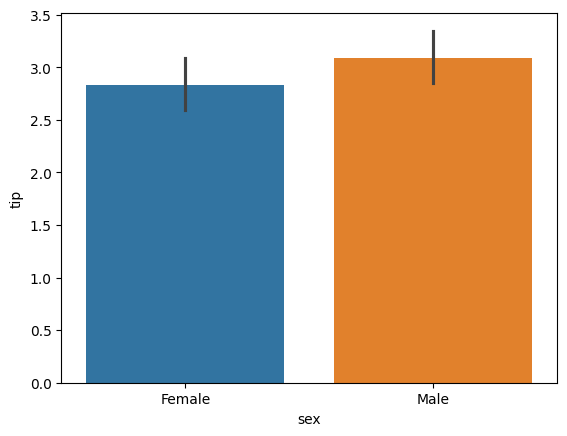

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x=tips['sex'], y=tips['tip'], hue=tips['sex'])
plt.show()

- 성별로 나누고 팁의 평균을 구함

In [ ]:
x = tips.groupby(by='sex')['tip'].mean()
print(x)

sex
Female    2.833448
Male      3.089618
Name: tip, dtype: float64


- estimator 인수 막대그래프의 y축의 값을 꼐산하는 함수

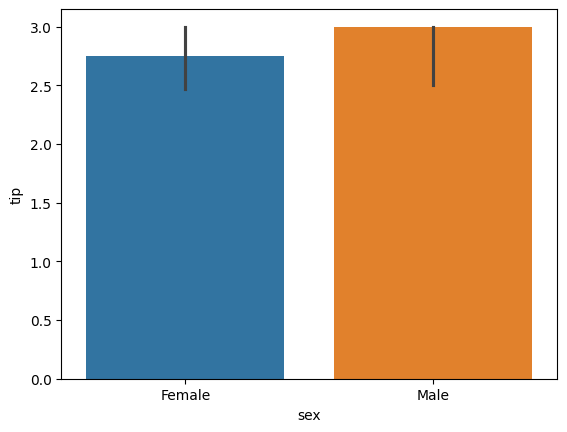

In [ ]:
import numpy as np

sns.barplot(x=tips['sex'], y=tips['tip'], hue=tips['sex'], estimator=np.median)
plt.show()

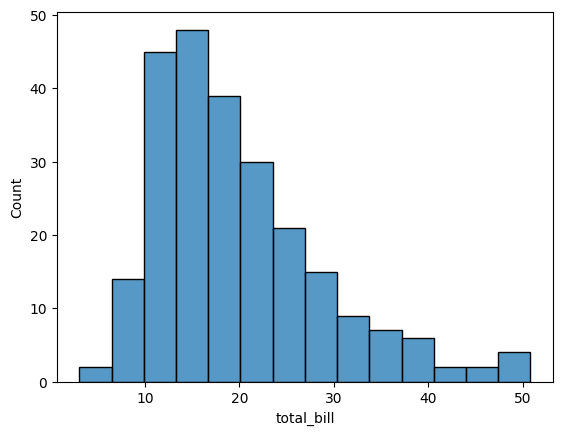

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x='total_bill', data=tips)
plt.show()

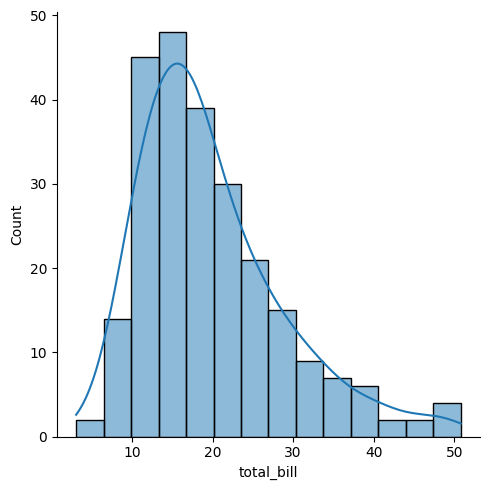

In [ ]:
sns.displot(data=tips, x = 'total_bill', kde=True)
plt.show()

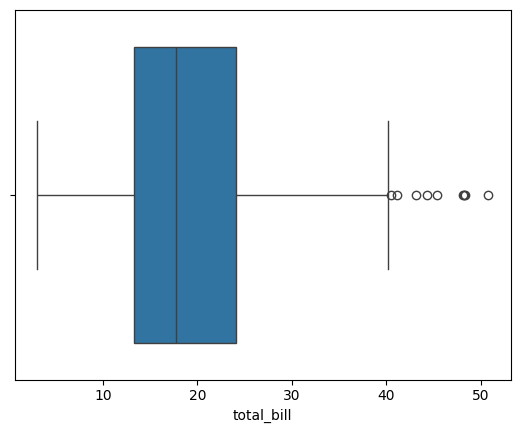

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x = tips['total_bill'])
plt.show()

- boxplot by group

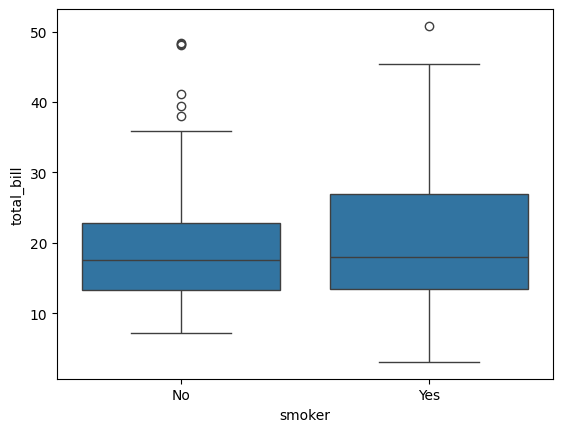

In [ ]:
sns.boxplot(x = 'smoker', y = 'total_bill', data=tips)
plt.show()

### 5. 바이올린 플롯 (Violin plot)
  - similar to boxplot to express informations
  - hue 인수 : grouping datas

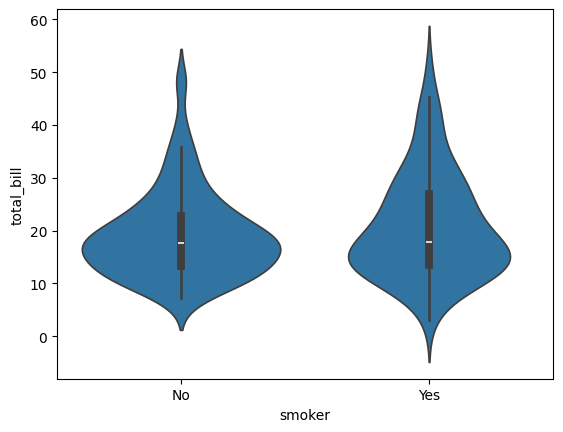

In [ ]:
sns.violinplot(x = 'smoker', y = 'total_bill', data=tips)
plt.show()

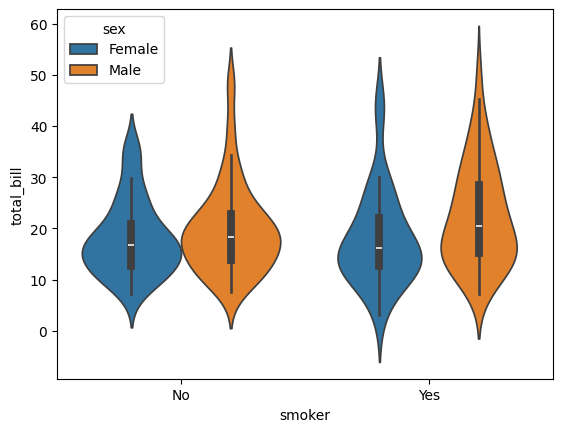

In [ ]:
sns.violinplot(x='smoker', y = 'total_bill', hue = 'sex', data=tips)
plt.show()

### 6.  히트맵 (Heatmap)
  - 열을 뜻하는 히드와 지도를 뜻하는 맵을 결합시킨 단어
  - 데이터의 값을 색상의 강도로 변환하여 열 분포형태로 보여주는 데이터 시각화 기법
  - 수치 데이터의 밀도나 크기를 한눈에 파악하기 좋음
  - 주식시장 트렌드나 웹 사용자 행동 분석에 아주 좋음

In [ ]:
df = tips.select_dtypes(['number'])
df.head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


- 양/음 상관관계를 표현하는 것이 통계의 기본

**상관계수 (Correlation Coefficient)**
- 두 변수 간 선형적 관계의 강도와 방향을 숫자로 나타낸 통계적 척도

=> 궁극적으로, 히트맵으로 표현하겠다는 것이 목표

In [ ]:
x = df.corr()
x

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


- heatmap()
  - 상관계수의 2차원 데이터를 히트맵으로 표시

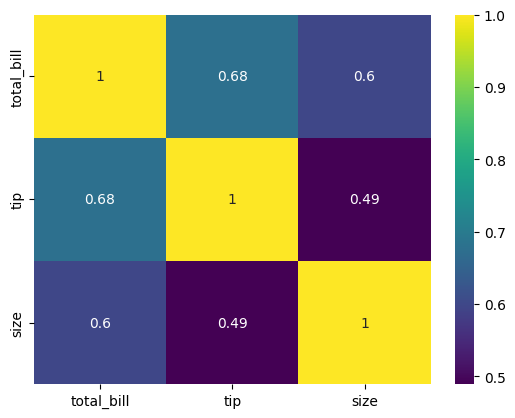

In [ ]:
sns.heatmap(x,annot=True, cmap='viridis')
plt.show()
#annot : 수치 표시
#cmap : 색상 표시방법

**결측치 표시**
- 결측치를 표시하는 특별한 형태의 그래프로 표현
- 타이타닉 데이터 사용
https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv

<Axes: >

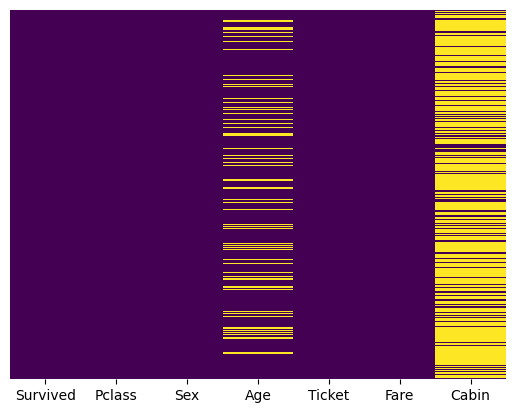

In [27]:
titanic = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv')
df = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'Ticket', 'Fare', 'Cabin']]
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [32]:
# titanic = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv')
titanic=sns.load_dataset('titanic')
df = titanic[['survived',  'sex', 'age',  'fare', 'deck']]
# sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
df



,survived,sex,age,fare,deck
0,0,male,22.0,7.2500,NaN
1,1,female,38.0,71.2833,C
2,1,female,26.0,7.9250,NaN
3,1,female,35.0,53.1000,C
4,0,male,35.0,8.0500,NaN
...,...,...,...,...,...
886,0,male,27.0,13.0000,NaN
887,1,female,19.0,30.0000,B
888,0,female,NaN,23.4500,NaN
889,1,male,26.0,30.0000,C


### 7. 패싯그리드(FacetGrid)
  - Col인수과 Row 인수를 설정하여 하나의 그림에 그룹별로 여러 개의 그래프를 그린다.
  - 데이터의 특정 범주(카테고리)를 기준으로 전체 데이터를 행과 열 형태의 격자로 나누어 여러개의 서브플롯을 한 번에 그릴 수 있음
  

**산점도**
- 성별과 시간에 따라 지불 금액 차이를 표현

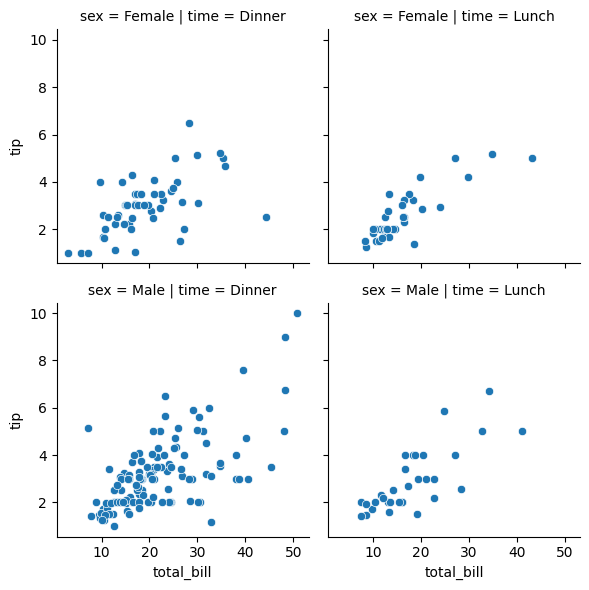

In [34]:
g = sns.FacetGrid(tips, col='time', row='sex')
g.map(sns.scatterplot, 'total_bill', 'tip')
plt.show()

- 히스토그램

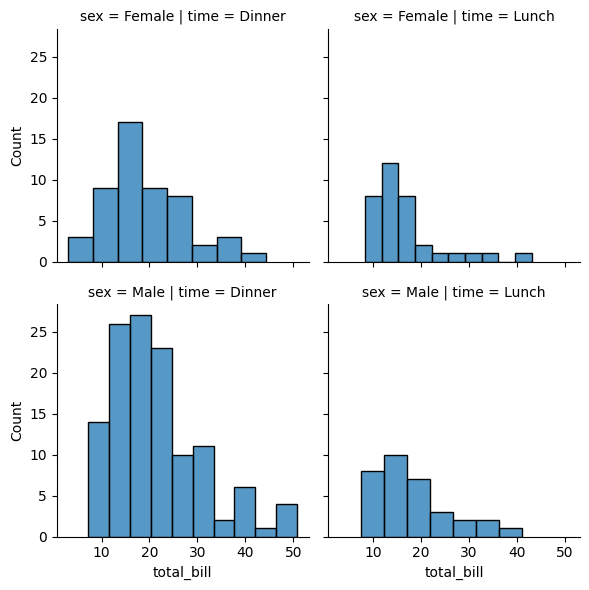

In [36]:
g = sns.FacetGrid(tips, col='time', row='sex')
g.map_dataframe(sns.histplot, x='total_bill')
plt.show()

- map vs map_dataframe
  - read() readline() readlines().. : open file function => 각자 반환값이 다름
  - 이와 비슷하게, map과 map_dataframe은 반환값이 다름

- Seaborn의 FacetGrid에서
  - map()과 map_dataframe()은 격자(Grid)에 그래프를 그리는 핵심 메서드이지만, 데이터를 함수에 전달하는 방식에 결정적인 차이가 있다.
  - map()은 데이터의 값(배열)을 순서대로 전달
  - map_dataframe()은 데이터프레임 자체와 열의 이름을 전달

### 8. 페어플롯 (Pair Plot)

  - 그리드형태로 각 컬럼의 조합에 대해 히스토그램과 분포도를 그린다.
  - 수치형 컬럼에 대해서만 그래프를 그린다.
  - 다변량 데이터셋에서 여러 수치형 변수들의 조합을 한눈에 비교하고 분석할 수 있도록 돕는 그리드 형태의 산접도 행렬
  - 다변량(Multivatiate)
    - 두 개 이상의 서로 관련된 여러 변수를 동시에 다루거나 분석하는 것

- 데이터 준비 : iris
  - Fisher의 유명한 아이리스 데이터셋
  - 150개의 붓꽃 샘플을 기반으로 세 종류의 붓꽃(Setosa,Versicolor,Virginica)을 분류하는 문제를 해결하는 데 자주 사용
  - 각 샘플은 꽃받침 길이, 꽃밭침 너비, 꽃잎 길이로 구성되어 있음
---
- 주요 열:
  - sepal_lenth - 꽃받침의 길이(cm)
  - sepal_width - 꽃받침의 너비 (cm)
  - petal_length - 꽃잎의 길이 (cm)
  - petal_width - 꽃잎의 너비 (cm)
  - species - 붓꽃의 종류 (Setosa, Versicolor, Virginica)
  

- 품종 별 특징
  - iris-Setosa(세토사)
    : 다른 품종에 비해 꽃잎과 꽃받침 크기가 확연히 작음
  - iris-Versicolor(버시컬러)
    : Setosa와 Virginica의 중간 크기를 가지며 혼동하기 쉬움
  - iris-Virginica(버지니카)
    : 세 가지 품종 중 크기가 가장 크고 화려함

In [37]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


- pairplot()함수

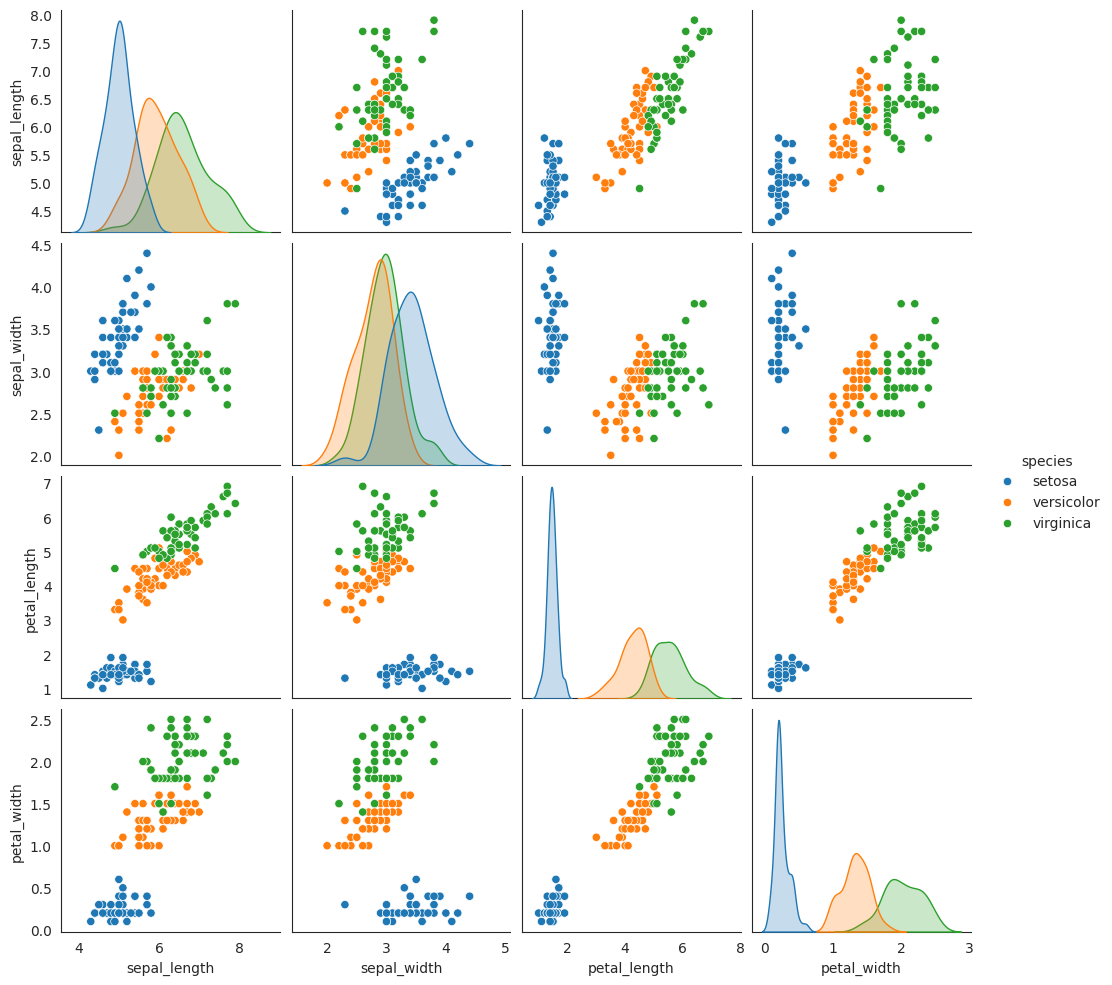

In [39]:
sns.set_style('white')
sns.pairplot(iris,hue='species')
plt.show()

- Pair Plot이란?
  : 데이터셋에 포함된 여러 수치형 변수들의 조합을 격자형태로 나열하여 변수 간 관계와 분포를 한 눈에 파악할 수 있게 해주는 시각화 기법

---
### 1. 비대각선 영역 (Off-Diagonal) : 산점도 (Scatter Plot)
- 대각선을 제외한 나머지 칸? 서로 다른 두 변수 조합으로 이루어짐
- 상관관계
  - 점들이 오른쪽 위로 향하면 양의 상관관계, 오른쪽 아래로 향하면 음의 상관관계
  - 원형으로 퍼져 있다면 두 변수 간 관계가 없음
  - 군집 및 이상치 호가인

### 2. 대각선 영역 (Diagonal): 단변량 분호 (Histogram/KDE)
- 행과 열의 변수가 일치하는 대각선 칸은 자기 자신의 변수 하나만을 분석한 그래프가 나타냄
- 주로 히스토그램 또는 KDE(밀도 곡선)가 사용됨
- 데이터 분포 형태
  - 데이터가 종 모양 정규분포를 띠는지, 한쪽으로 치우쳐져 있는지, 봉우리가 여러개인지 등

### 3. 색상 구분 (Hue)
- hue 파라미터를 사용해 범주형 변수 기준으로 색상을 다르게 지정함